# Lab 5: Fuzzy Inference Systems

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import skfuzzy as fuzz


In [2]:
plt.rcParams['figure.figsize'] = [10, 5]
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

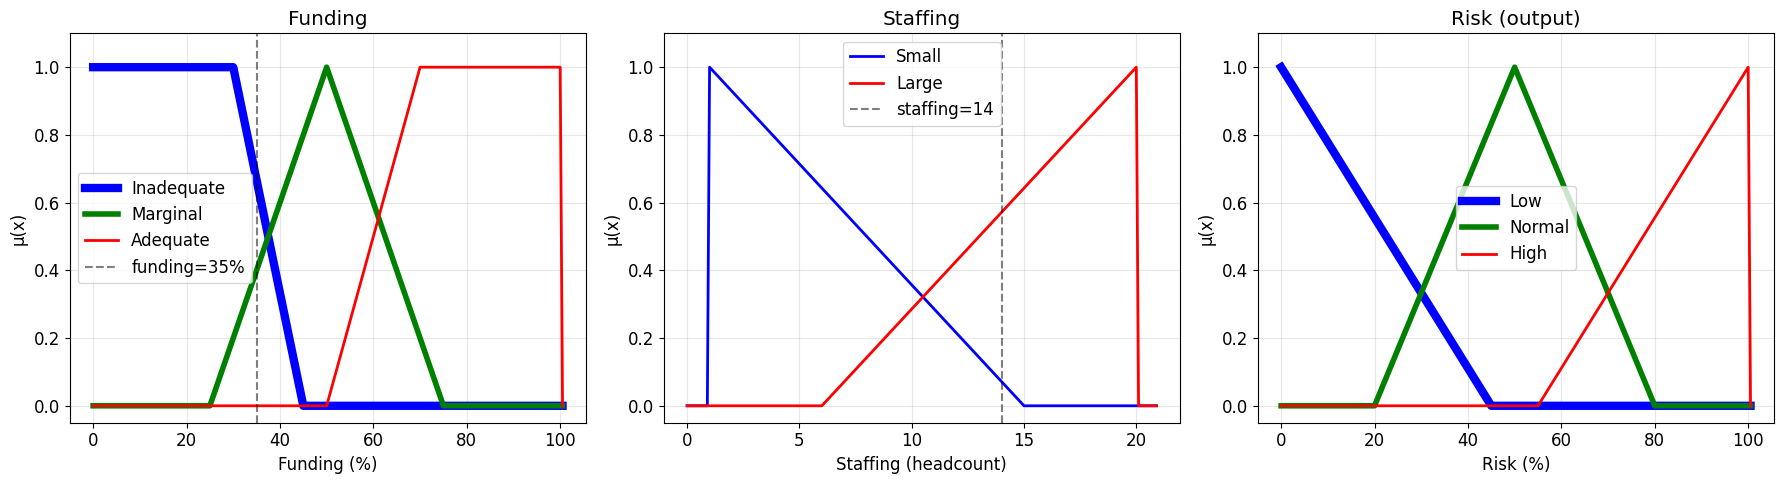

In [3]:
# Universes of discourse
x_fund  = np.arange(0, 101, 0.5)
x_staff = np.arange(0, 21, 0.1)
x_risk  = np.arange(0, 101, 0.5)
# --- Funding MFs --
# Inadequate: (0,1)→(30,1)→(45,0) — trapezoidal left-shoulder
fund_inadequate = fuzz.trapmf(x_fund, [0, 0, 30, 45])
# Marginal: triangle (25, 50, 75)
fund_marginal = fuzz.trimf(x_fund, [25, 50, 75])
# Tip: use skfuzzy's "trimf" function
# Adequate: (50,0)→(70,1)→(100,1) — trapezoidal right-shoulder
fund_adequate = fuzz.trapmf(x_fund, [50, 70, 100, 100])
# --- Staffing MFs --
# Small: (1,1)→(15,0) left-shoulder trapezoid
staff_small = fuzz.trapmf(x_staff, [1, 1, 1, 15])
# Large: (6,0)→(20,1) right-shoulder trapezoid
staff_large = fuzz.trapmf(x_staff, [6, 20, 20, 20])
# --- Risk MFs --
# Low: (0,1)→(45,0) left-shoulder trapezoid
# top plateau from 0 to 1, then decline to 0 at 45
risk_low = fuzz.trapmf(x_risk, [0, 0, 0, 45])
# Normal: triangle (20, 50, 80)
risk_normal = fuzz.trimf(x_risk, [20, 50, 80])
# High: (55,0)→(100,1) right-shoulder trapezoid
risk_high = fuzz.trapmf(x_risk, [55, 100, 100, 100])
# --- Plot --
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
ax1.plot(x_fund, fund_inadequate, 'b-', lw=6, label='Inadequate')
ax1.plot(x_fund, fund_marginal,   'g-', lw=4, label='Marginal')
ax1.plot(x_fund, fund_adequate,   'r-', lw=2, label='Adequate')
ax1.axvline(x=35, color='k', ls='--', alpha=0.5, label='funding=35%')
ax1.set_title('Funding')
ax1.set_xlabel('Funding (%)')
ax1.set_ylabel('μ(x)')
ax1.legend()
ax2.plot(x_staff, staff_small, 'b-', lw=2, label='Small')
ax2.plot(x_staff, staff_large, 'r-', lw=2, label='Large')
ax2.axvline(x=14, color='k', ls='--', alpha=0.5, label='staffing=14')
ax2.set_title('Staffing')
ax2.set_xlabel('Staffing (headcount)')
ax2.set_ylabel('μ(x)')
ax2.legend()
ax3.plot(x_risk, risk_low,    'b-', lw=6, label='Low')
ax3.plot(x_risk, risk_normal, 'g-', lw=4, label='Normal')
ax3.plot(x_risk, risk_high,   'r-', lw=2, label='High')
ax3.set_title('Risk (output)')
ax3.set_xlabel('Risk (%)')
ax3.set_ylabel('μ(x)')
ax3.legend()
for ax in [ax1, ax2, ax3]:
    ax.set_ylim(-0.05, 1.1)
plt.tight_layout()
plt.show()

In [4]:
# Crisp inputs
funding_val = 35
staffing_val = 14
# Fuzzify funding
# Calculate the degree of membership (DoM) for "inadequate"
mu_inadequate = fuzz.interp_membership(x_fund, fund_inadequate, funding_val)
# TODO: Calculate DoM for "marginal" here
mu_marginal = fuzz.interp_membership(x_fund, fund_marginal, funding_val)
# TODO: Calculate DoM for "adequate" here
mu_adequate = fuzz.interp_membership(x_fund, fund_adequate, funding_val)
# Fuzzify staffing

# TODO: Calculate DoM for "small" here
mu_small = fuzz.interp_membership(x_staff, staff_small, staffing_val)
# TODO: Calculate DoM for "large" here
mu_large = fuzz.interp_membership(x_staff, staff_large, staffing_val)
print(f"Fuzzification: funding = {funding_val}%, staffing = {staffing_val}")
print(f"{'─' * 45}")
print(f"  μ_inadequate({funding_val}) = {mu_inadequate:.4f}")
print(f"  μ_marginal({funding_val})   = {mu_marginal:.4f}")
print(f"  μ_adequate({funding_val})   = {mu_adequate:.4f}")
print()
print(f"  μ_small({staffing_val})     = {mu_small:.4f}")
print(f"  μ_large({staffing_val})     = {mu_large:.4f}")

Fuzzification: funding = 35%, staffing = 14
─────────────────────────────────────────────
  μ_inadequate(35) = 0.6667
  μ_marginal(35)   = 0.4000
  μ_adequate(35)   = 0.0000

  μ_small(14)     = 0.0714
  μ_large(14)     = 0.5714


Rule evaluation:
  Rule 1: max(adequate=0.000, small=0.071) = 0.071 → clip 'low'
  Rule 2: min(marginal=0.400, large=0.571) = 0.400 → clip 'normal'
  Rule 3: inadequate = 0.667 → clip 'high'


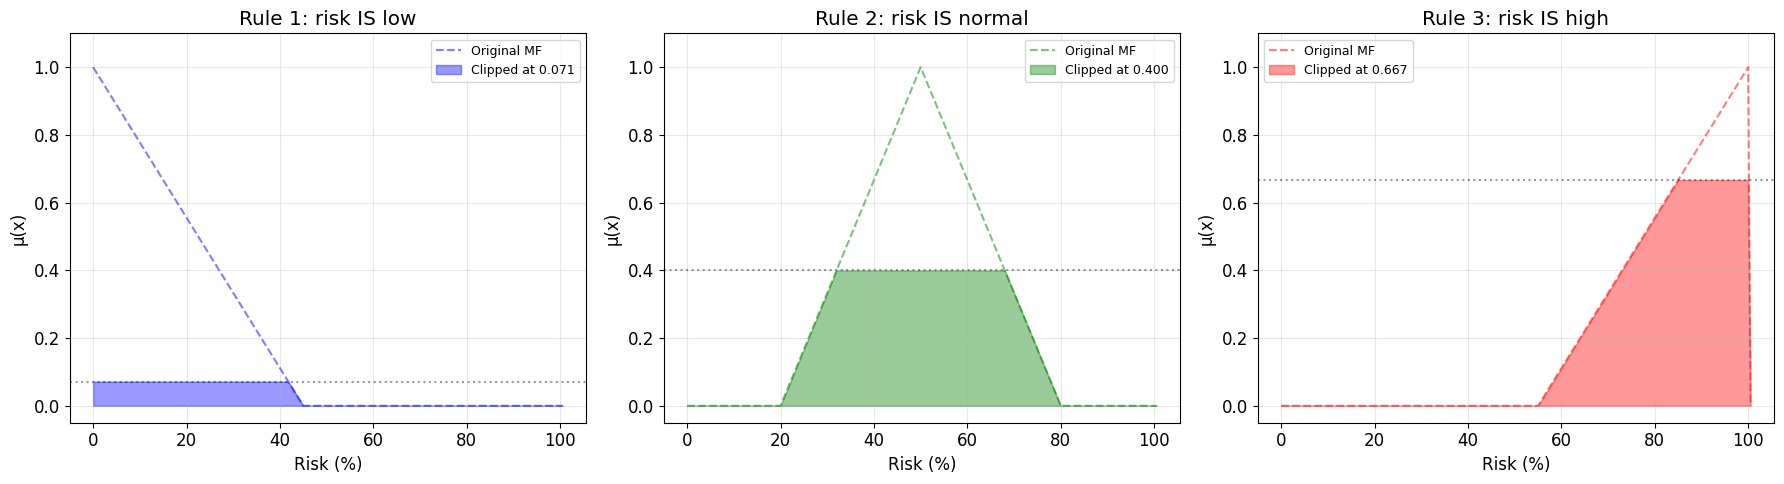

In [5]:
# Rule 1: IF funding IS adequate OR (max) staffing IS small THEN risk IS low
rule1_strength = max(mu_adequate, mu_small)
rule1_output = np.minimum(rule1_strength, risk_low)  # Clip (min-implication)
# Rule 2: IF funding IS marginal AND (min) staffing IS large THEN risk IS normal
# TODO: Code Rule 2 here
rule2_strength = min(mu_marginal, mu_large)
rule2_output = np.minimum(rule2_strength, risk_normal)  # Clip
# Rule 3: IF funding IS inadequate THEN risk IS high
rule3_strength = mu_inadequate
rule3_output = np.minimum(rule3_strength, risk_high)  # Clip
print("Rule evaluation:")
print(f"  Rule 1: max(adequate={mu_adequate:.3f}, small={mu_small:.3f}) " \
      f"= {rule1_strength:.3f} → clip 'low'")
print(f"  Rule 2: min(marginal={mu_marginal:.3f}, large={mu_large:.3f}) " \
      f"= {rule2_strength:.3f} → clip 'normal'")
print(f"  Rule 3: inadequate = {rule3_strength:.3f} → clip 'high'")
# Plot clipped consequents
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['Rule 1: risk IS low', 'Rule 2: risk IS normal', 'Rule 3: risk IS high']
originals = [risk_low, risk_normal, risk_high]
clipped = [rule1_output, rule2_output, rule3_output]
strengths = [rule1_strength, rule2_strength, rule3_strength]
colors = ['blue', 'green', 'red']
for ax, title, orig, clip, strength, color in zip(axes, titles, originals, 
                                                  clipped, strengths, colors):
    ax.plot(x_risk, orig, color=color, ls='--', lw=1.5, alpha=0.5, label='Original MF')
    ax.fill_between(x_risk, clip, alpha=0.4, color=color, label=f'Clipped at {strength:.3f}')
    ax.axhline(y=strength, color='k', ls=':', alpha=0.4)
    ax.set_title(title)
    ax.set_xlabel('Risk (%)')
    ax.set_ylabel('μ(x)')
    ax.set_ylim(-0.05, 1.1)
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

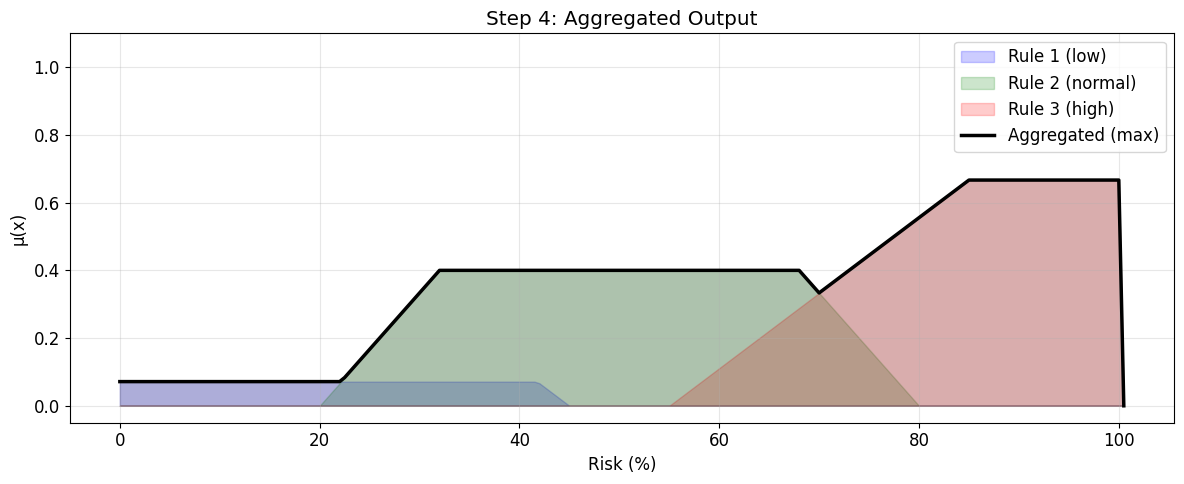

In [6]:
# Aggregate using max
# TODO: Calculate the "aggregated" result by using numpy's "maximum" function
#       on the Rules 1, 2, and 3 outputs
aggregated = np.maximum.reduce([rule1_output, rule2_output, rule3_output])
# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(x_risk, rule1_output, alpha=0.2, color='blue', label='Rule 1 (low)')
ax.fill_between(x_risk, rule2_output, alpha=0.2, color='green', label='Rule 2 (normal)')
ax.fill_between(x_risk, rule3_output, alpha=0.2, color='red', label='Rule 3 (high)')
ax.plot(x_risk, aggregated, 'k-', lw=2.5, label='Aggregated (max)')
ax.fill_between(x_risk, aggregated, alpha=0.15, color='black')
ax.set_title('Step 4: Aggregated Output')
ax.set_xlabel('Risk (%)')
ax.set_ylabel('μ(x)')
ax.set_ylim(-0.05, 1.1)
ax.legend()
plt.tight_layout()
plt.show()

Defuzzification results (funding=35%, staffing=14):
  COG (Centre of Gravity):  64.89%
  MOM (Mean of Maxima):     92.50%
  SOM (Smallest of Maxima): 85.00%
  LOM (Largest of Maxima):  100.00%


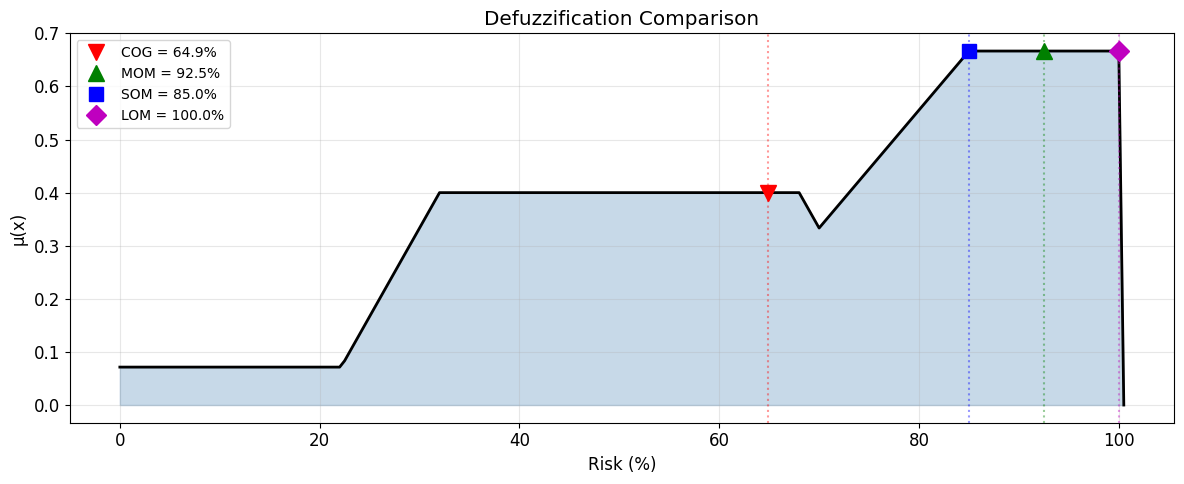

In [7]:
def defuzzify_cog(x, mf):
    """Centre of Gravity (centroid) defuzzification."""
    if np.sum(mf) == 0:
        return 0
    # TODO: Compute and return the COG result using the
    #       numpy's "sum" function twice here
    # Tip: See the COG equation in the MD cell above,
    #      where "z" there is the "x" attribute here
    numerator = np.sum(x * mf)
    denominator = np.sum(mf)
    return numerator / denominator
    
def defuzzify_mom(x, mf):
    """Mean of Maxima defuzzification."""
    max_val = np.max(mf)
    if max_val == 0:
        return 0
    max_indices = np.where(np.isclose(mf, max_val, atol=1e-6))[0]
    return np.mean(x[max_indices])
def defuzzify_som(x, mf):
    """Smallest of Maxima defuzzification."""
    max_val = np.max(mf)
    if max_val == 0:
        return 0
    max_indices = np.where(np.isclose(mf, max_val, atol=1e-6))[0]
    return x[max_indices[0]]
def defuzzify_lom(x, mf):
    """Largest of Maxima defuzzification."""
    max_val = np.max(mf)
    if max_val == 0:
             return 0
    max_indices = np.where(np.isclose(mf, max_val, atol=1e-6))[0]
    return x[max_indices[-1]]
# Compute all four
# Compute COG
cog = defuzzify_cog(x_risk, aggregated)
# TODO: Compute MOM
mom = defuzzify_mom(x_risk, aggregated)
# TODO: Compute SOM
som = defuzzify_som(x_risk, aggregated)
# TODO: Compute LOM
lom = defuzzify_lom(x_risk, aggregated)

print(f"Defuzzification results (funding={funding_val}%, staffing={staffing_val}):")
print(f"  COG (Centre of Gravity):  {cog:.2f}%")
print(f"  MOM (Mean of Maxima):     {mom:.2f}%")
print(f"  SOM (Smallest of Maxima): {som:.2f}%")
print(f"  LOM (Largest of Maxima):  {lom:.2f}%")
# Plot with defuzzification points
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(x_risk, aggregated, alpha=0.3, color='steelblue')
ax.plot(x_risk, aggregated, 'k-', lw=2)
markers = {'COG': (cog, 'rv', 12), 'MOM': (mom, 'g^', 12), 
           'SOM': (som, 'bs', 10), 'LOM': (lom, 'mD', 10)}
for name, (val, marker, ms) in markers.items():
    ax.plot(val, fuzz.interp_membership(x_risk, aggregated, val), 
            marker, markersize=ms, label=f'{name} = {val:.1f}%')
    ax.axvline(x=val, color=marker[0], ls=':', alpha=0.4)
ax.set_title('Defuzzification Comparison')
ax.set_xlabel('Risk (%)')
ax.set_ylabel('μ(x)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

import sys
!{sys.executable} -m pip install pyfuzzylite --no-deps

In [8]:
# pip install pyfuzzylite --no-deps
import fuzzylite as fl
from fuzzylite import settings
import warnings

# Suppress numpy deprecation warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

# Register custom hedges to match lecture slide definitions
settings.factory_manager.hedge.constructors["slightly"] = \
    lambda: fl.HedgeLambda("slightly", lambda x: x**1.7)
settings.factory_manager.hedge.constructors["a_little"] = \
    lambda: fl.HedgeLambda("a_little", lambda x: x**1.3)
#TODO: Register the custom "More or Less" hedge (x^0.5)
settings.factory_manager.hedge.constructors["more_or_less"] = \
    lambda: fl.HedgeLambda("more_or_less", lambda x: x**0.5)
# TODO: Override "Extremely" to match slides (x^3) instead of pyfuzzylite's default
settings.factory_manager.hedge.constructors["extremely"] = \
    lambda: fl.HedgeLambda("extremely", lambda x: x**3)
# Register additional hedges from the slides
settings.factory_manager.hedge.constructors["very_very"] = \
    lambda: fl.HedgeLambda("very_very",    lambda x: x**4)
# Built-in hedges that already match slides: very (x^2), somewhat (x^(1/3)), not (1-x)
print("Registered hedges:", list(settings.factory_manager.hedge.constructors.keys()))

Registered hedges: ['any', 'extremely', 'not', 'seldom', 'somewhat', 'very', 'slightly', 'a_little', 'more_or_less', 'very_very']


In [9]:
# Project staffing Mamdani system
staffing_engine = fl.Engine(
    name="ProjectStaffing",
    input_variables=[
        fl.InputVariable(
            name="funding", minimum=0.0, maximum=100.0,
            terms=[
                fl.Trapezoid("inadequate", 0, 0, 30, 45),
                # TODO: using pyfuzzylite's "Triangle" function,
                #       define here the "Marginal" fuzzy set with
                #       the same parameters as in Part A, Step 1
                    fl.Triangle("marginal", 25, 50, 75),
                
                # TODO: using pyfuzzylite's "Trapezoid" function,
                #       define here the "Adequate" fuzzy set with
                #       the same parameters as in Part A, Step 1
                fl.Trapezoid("adequate", 55, 70, 85, 100)
                
            ]
        ),
        fl.InputVariable(
            name="staffing", minimum=1.0, maximum=20.0,
            terms=[
                fl.Ramp("small", 15, 1),     # Descending: from 1(=1.0) to 15(=0.0)
                fl.Ramp("large", 6, 20),      # Ascending: from 6(=0.0) to 20(=1.0)
                 ]
        ),
    ],
    output_variables=[
        fl.OutputVariable(
            name="risk", minimum=0.0, maximum=100.0,
            aggregation=fl.Maximum(),
            defuzzifier=fl.Centroid(500),
            terms=[
                fl.Ramp("low", 45, 0),        # Descending: from 0(=1.0) to 45(=0.0)
                # TODO: using pyfuzzylite's "Triangle" function,
                #       define here the "Normal" fuzzy set with
                #       the same parameters as in Part A, Step 1
                fl.Triangle("normal", 20, 50, 80),
                
                # TODO: using pyfuzzylite's "Ramp" function,
                #       define here the "High" fuzzy set with
                #       the same parameters as in Part A, Step 1
                # Ascending: from 55(=0.0) to 100(=1.0)
                fl.Ramp("high", 55, 100)
                
            ]
        ),
    ],
    rule_blocks=[
        fl.RuleBlock(
            name="rules",
            conjunction=fl.Minimum(),       # AND = min
            disjunction=fl.Maximum(),       # OR  = max
            implication=fl.Minimum(),       # Clip (min-implication)
            activation=fl.General(),
            rules=[
                fl.Rule.create(
                    ("if funding is adequate or staffing is small "
                     "then risk is low")
                ),
                fl.Rule.create(
                    ("if funding is marginal and staffing is large "
                     "then risk is normal")
                ),
                fl.Rule.create("if funding is inadequate then risk is high"),
            ]
        ),
    ]
)
# Run inference
staffing_engine.input_variable("funding").value = 35.0
staffing_engine.input_variable("staffing").value = 14.0
staffing_engine.process()
pfl_cog = staffing_engine.output_variable("risk").value.item()
print(f"pyfuzzylite COG result: {pfl_cog:.2f}%")
print(f"From-scratch COG result: {cog:.2f}%")
print(f"Difference: {abs(pfl_cog - cog):.4f}%")
# Try all defuzzifiers
for name, defuzz in [("COG", fl.Centroid(500)), ("MOM", fl.MeanOfMaximum(500)),
                      ("SOM", fl.SmallestOfMaximum(500)), ("LOM", fl.LargestOfMaximum(500)),
                      ("Bisector", fl.Bisector(500))]:
    staffing_engine.output_variable("risk").defuzzifier = defuzz
    staffing_engine.process()
    val = staffing_engine.output_variable("risk").value.item()
    print(f"  {name:10s}: {val:.2f}%")


pyfuzzylite COG result: 64.76%
From-scratch COG result: 64.89%
Difference: 0.1281%
  COG       : 64.76%
  MOM       : 92.50%
  SOM       : 85.10%
  LOM       : 99.90%
  Bisector  : 67.90%


In [10]:
dapping_engine = fl.Engine(
    name="Dapping",
    input_variables=[
        fl.InputVariable(
            name="wind", minimum=0.0, maximum=12.0,
            terms=[
                fl.Trapezoid("calm", 0, 0, 2, 5),
                fl.Triangle("fresh", 2, 6, 10),
                fl.Trapezoid("stormy", 6, 10, 12, 12),
            ]
        ),
        fl.InputVariable(
            name="temperature", minimum=0.0, maximum=30.0,
            terms=[
                # low: membership 1 from 0 up to 5, then drop to 0 by 15
                fl.Trapezoid("low", 0, 0, 5, 15),

                # average: triangular peak at 15 with zero at 5 and 25
                fl.Triangle("average", 5, 15, 25),

                # high: 0 until 18, rise to 1 at 24, plateau through 30
                fl.Trapezoid("high", 18, 24, 30, 30),
            ]
        ),
    ],
    output_variables=[
        fl.OutputVariable(
            name="dapping", minimum=0.0, maximum=100.0,
            aggregation=fl.Maximum(),
            defuzzifier=fl.Centroid(500),
            terms=[
                fl.Trapezoid("poor", 0, 0, 10, 30),
                fl.Triangle("mediocre", 20, 50, 80),
                fl.Trapezoid("excellent", 70, 90, 100, 100),
            ]
        ),
    ],
    rule_blocks=[
        fl.RuleBlock(
            name="rules",
            conjunction=fl.Minimum(),
            disjunction=fl.Maximum(),
            implication=fl.Minimum(),
            activation=fl.General(),
            rules=[
                fl.Rule.create( ("if wind is extremely stormy or temperature is very low "
                     "then dapping is not very poor")
                ),
                fl.Rule.create(
                    ("if wind is fresh and temperature is more_or_less average "
                     "then dapping is mediocre")
                ),
                fl.Rule.create(
                    ("if wind is slightly stormy and temperature is not low "
                     "then dapping is a_little excellent")
                ),
            ]
        ),
    ]
)
# Run with some crisp inputs
dapping_engine.input_variable("wind").value = 8.0
dapping_engine.input_variable("temperature").value = 10.0
dapping_engine.process()
mamdani_cog = dapping_engine.output_variable("dapping").value.item()
print(f"Dapping Mamdani COG (wind=8, temp=10): {mamdani_cog:.2f}%")
print()
print("All Mamdani defuzzifiers:")
for name, defuzz in [
    ("COG", fl.Centroid(500)), ("MOM", fl.MeanOfMaximum(500)), 
    ("SOM", fl.SmallestOfMaximum(500)), ("LOM", fl.LargestOfMaximum(500))
]:
    dapping_engine.output_variable("dapping").defuzzifier = defuzz
    dapping_engine.process()
    val = dapping_engine.output_variable("dapping").value.item()
    print(f"  {name}: {val:.2f}%")

Dapping Mamdani COG (wind=8, temp=10): 38.29%

All Mamdani defuzzifiers:
  COG: 38.29%
  MOM: 5.60%
  SOM: 0.10%
  LOM: 11.10%


In [11]:
# Dapping Sugeno (zero-order)
# The input variables (wind, temperature) are identical to the Mamdani engine above.
# Only the output variable differs: Sugeno uses singleton constants instead of fuzzy
# sets, and a weighted average defuzzifier instead of centroid.
dapping_sugeno = fl.Engine(
    name="DappingSugeno",
    input_variables=[ # Same input MFs as the Mamdani engine
        fl.InputVariable(
            name="wind", minimum=0.0, maximum=12.0,
            terms=[t for t in dapping_engine.input_variable("wind").terms]
        ),
        fl.InputVariable(
            name="temperature", minimum=0.0, maximum=30.0,
            terms=[t for t in dapping_engine.input_variable("temperature").terms]
        ),
    ],
    output_variables=[
        fl.OutputVariable(
            name="dapping", minimum=0.0, maximum=100.0,
            aggregation=None,       # No aggregation for Sugeno
            defuzzifier=fl.WeightedAverage("TakagiSugeno"),
            terms=[
                fl.Constant("poor", 25),        # Singleton at 25
                fl.Constant("mediocre", 50),     # Singleton at 50
                fl.Constant("excellent", 75),    # Singleton at 75
            ]
        ),
    ],
    rule_blocks=[
        fl.RuleBlock(
            name="rules",
            conjunction=fl.Minimum(),
            disjunction=fl.Maximum(),
            implication=None,       # No implication for Sugeno
            activation=fl.General(),
            rules=[
                fl.Rule.create(
                    ("if wind is extremely stormy or temperature "
                     "is very low then dapping is poor")
                ),
                fl.Rule.create(
                    ("if wind is fresh and temperature "
                     "is more_or_less average then dapping is mediocre")
                ),
                fl.Rule.create(
                    ("if wind is slightly stormy and temperature "
                     "is not low then dapping is a_little excellent")
                ),
            ]
        ),
    ]
)
dapping_sugeno.input_variable("wind").value = 8.0
dapping_sugeno.input_variable("temperature").value = 10.0
dapping_sugeno.process()

sugeno_result = dapping_sugeno.output_variable("dapping").value.item()
print(f"Dapping Sugeno (wind=8, temp=10): {sugeno_result:.2f}%")
print()
# Manual verification — compute firing strengths from the engine's own MFs
wind_val, temp_val = 8.0, 10.0
mu_stormy = fl.Trapezoid("stormy", 6, 10, 12, 12).membership(wind_val)
mu_fresh  = fl.Triangle("fresh", 2, 6, 10).membership(wind_val)
mu_low    = fl.Trapezoid("low", 0, 0, 5, 15).membership(temp_val)
mu_avg    = fl.Triangle("average", 5, 15, 25).membership(temp_val)
# Rule 1: extremely stormy OR very low → poor
ext_stormy = float(mu_stormy) ** 3
very_low   = float(mu_low) ** 2
w1 = max(ext_stormy, very_low)
# Rule 2: fresh AND more_or_less average → mediocre
mol_avg = float(mu_avg) ** 0.5
w2 = min(float(mu_fresh), mol_avg)
# Rule 3: slightly stormy AND NOT low → a_little excellent
sl_stormy  = float(mu_stormy) ** 1.7
not_low    = 1 - float(mu_low)
r3_and     = min(sl_stormy, not_low)
w3 = r3_and ** 1.3
z1, z2, z3 = 25, 50, 75
manual_sugeno = (w1*z1 + w2*z2 + w3*z3) / (w1 + w2 + w3)
print("Manual Sugeno verification:")
print(
    (f"  Rule 1: w1 = {w1:.4f}  (extremely stormy={ext_stormy:.4f}, "
     f"very low={very_low:.4f})")
)
print(
    (f"  Rule 2: w2 = {w2:.4f}  (fresh={float(mu_fresh):.4f}, "
     f"mol avg={mol_avg:.4f})")
)
print(
    (f"  Rule 3: w3 = {w3:.4f}  (sl stormy={sl_stormy:.4f}, "
     f"not low={not_low:.4f}, a_little={w3:.4f})")
)
print(
    (f"  WA = ({w1:.3f}\u00d7{z1} + {w2:.3f}\u00d7{z2} + {w3:.3f}\u00d7{z3}) "
     f"/ ({w1:.3f} + {w2:.3f} + {w3:.3f})")
)
print(f"     = {w1*z1 + w2*z2 + w3*z3:.3f} / {w1+w2+w3:.3f}")
print(f"     = {manual_sugeno:.2f}%")


Dapping Sugeno (wind=8, temp=10): 49.12%

Manual Sugeno verification:
  Rule 1: w1 = 0.2500  (extremely stormy=0.1250, very low=0.2500)
  Rule 2: w2 = 0.5000  (fresh=0.5000, mol avg=0.7071)
  Rule 3: w3 = 0.2161  (sl stormy=0.3078, not low=0.5000, a_little=0.2161)
  WA = (0.250×25 + 0.500×50 + 0.216×75) / (0.250 + 0.500 + 0.216)
     = 47.460 / 0.966
     = 49.12%
